# Building a Neural Network in Python



In [1]:
# Importing numpy and pandas libraries to read the data

# Supress Warnings
import warnings
warnings.filterwarnings('ignore')

# Import the numpy and pandas package
import numpy as np
import pandas as pd

# loading the dataset, careful about the path
toluca = pd.read_csv("toluca.csv")
toluca



,hours,parts
0,80,399
1,30,121
2,50,221
3,90,376
4,70,361
5,60,224
6,120,546
7,80,352
8,100,353
9,50,157


We now load Keras, and build our first neural networks
There are three steps
1) Design the network. Here we setup a shallow network with nh nodes, and a sigmoid (logit). Notice that I always need two layers: one with dimention nh, one with dimension 1 and linear activation function in the case of Gaussian NNs
2) Compile it. Meaning you define what type of loss function and optimizer. Here we use mse and adam. Up to this point we do not use any data
3) Fit it. You need to specify input, output, epochs (i.e., iterations), validation split, etc.

In [5]:
#Dependencies
import keras
from keras.models import Sequential
from keras.layers import Dense

# define the keras model
nh=500

model = Sequential()
model.add(Dense(nh, input_dim=1, activation='sigmoid'))
model.add(Dense(1, activation='linear'))

model.compile(loss='mse', optimizer='adam')

history = model.fit(toluca.hours, toluca.parts, epochs=10000, verbose=0)



# Convergence diagnostics

As we have argued in class, there is no gurantee of convergence after a given point. So one of your best ways to actually check for convergence is to look at how the loss function changes as a function of the epochs. 


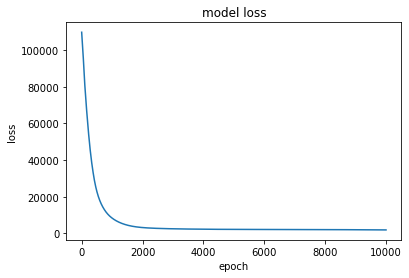

In [6]:
# Import matplotlib libraries to visualize the data
import matplotlib.pyplot as plt 

# summarize history for loss
plt.plot(history.history['loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.show()


# Visualize the fit

Finally, we can visualize the fitted data along with the original scatterplot


1/1 [==============================] - 0s 33ms/step


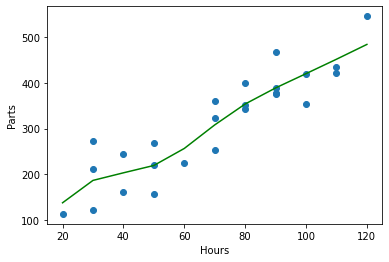

In [8]:
# Let's get the fitted data
y_pred_NN = model.predict(toluca.hours)

plt.plot(toluca.hours,toluca.parts,'o')
plt.xlabel('Hours')
plt.ylabel('Parts')

ind_plot=np.argsort(toluca.hours)
plt.plot(toluca.hours[ind_plot],y_pred_NN[ind_plot],color="green")


# Comparing with linear regression

Let's also fit a linear regression

In [9]:
# Importing Statsmodels.api library from Stamodel package
import statsmodels.api as sm

# Adding a constant to get an intercept
toluca_hours_sm = sm.add_constant(toluca.hours)

# Fitting the resgression line using 'OLS'
lr = sm.OLS(toluca.parts, toluca_hours_sm).fit()

# Printing the parameters
lr.params



const    62.365859
hours     3.570202
dtype: float64

# Plot

Now let's now plot the fitted linear regression line vs the predicted values according to the NN



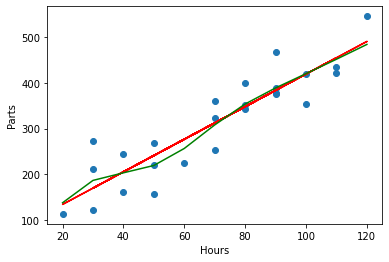

In [10]:
fitted_values = lr.predict(toluca_hours_sm)

plt.plot(toluca.hours,toluca.parts,'o')
plt.plot(toluca.hours,fitted_values,color="r")

plt.xlabel('Hours')
plt.ylabel('Parts')

# plotting the fit according to the NN
ind_plot=np.argsort(toluca.hours)
plt.plot(toluca.hours[ind_plot],y_pred_NN[ind_plot],color="green")

Let's now try different network configurations, what happens if we try a linear or reLU activation function? 

1/1 [==============================] - 0s 32ms/step


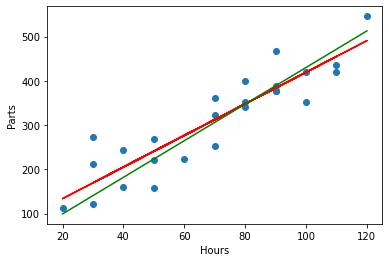

In [11]:

model2 = Sequential()
model2.add(Dense(nh, input_dim=1, activation='relu'))
model2.add(Dense(1, activation='linear'))
model2.compile(loss='mse', optimizer='adam')

history = model2.fit(toluca.hours, toluca.parts, epochs=2000, verbose=0)
y_pred2_NN = model2.predict(toluca.hours)

plt.plot(toluca.hours,toluca.parts,'o')
plt.plot(toluca.hours,fitted_values,color="r")

plt.xlabel('Hours')
plt.ylabel('Parts')

# plotting the fit according to the NN
ind_plot=np.argsort(toluca.hours)
plt.plot(toluca.hours[ind_plot],y_pred2_NN[ind_plot],color="green")


How about trying a deep network? This can be achieved simply by stacking two layers sequentially

1/1 [==============================] - 0s 38ms/step


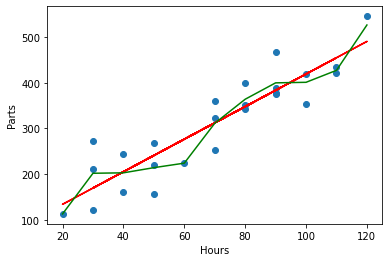

In [12]:
model3 = Sequential()
model3.add(Dense(nh, input_dim=1, activation='sigmoid'))
model3.add(Dense(nh, activation='sigmoid'))
model3.add(Dense(1, activation='linear'))
model3.compile(loss='mse', optimizer='adam')

history = model3.fit(toluca.hours, toluca.parts, epochs=8000, verbose=0)
y_pred3_NN = model3.predict(toluca.hours)

plt.plot(toluca.hours,toluca.parts,'o')
plt.plot(toluca.hours,fitted_values,color="r")

plt.xlabel('Hours')
plt.ylabel('Parts')

# plotting the fit according to the NN
ind_plot=np.argsort(toluca.hours)
plt.plot(toluca.hours[ind_plot],y_pred3_NN[ind_plot],color="green")
